In [409]:

import numpy as np
import torchaudio
import speechbrain as sb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from speechbrain.inference import SpeakerRecognition
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from torchaudio.transforms import MelSpectrogram, GriffinLim
import os
import torchaudio
import torch
from sklearn.model_selection import train_test_split
from speechbrain.pretrained import EncoderClassifier
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as transforms
import torchaudio
from speechbrain.inference.encoders import MelSpectrogramEncoder
from speechbrain.utils.fetching import fetch
from speechbrain.utils.data_utils import split_path


In [387]:
# Check GPU availability and set device accordingly
device = torch.device("mps")
print("Device:",device)

Device: mps


In [408]:
model_dir = "pretrained_models/spkrec-ecapa-mel-spec"
model = SpeakerRecognition.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb-mel-spec", savedir=model_dir)


/Users/ghs6kor/miniconda3/envs/spkver310/lib/python3.10/site-packages/speechbrain/processing/features.py:1311: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stats = torch.lo

Speaker 001
Speaker 002
Speaker 006
Speaker 027
Speaker 030
Speaker 049
Speaker 050
280
(280, 1, 1, 192)


/Users/ghs6kor/miniconda3/envs/spkver310/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


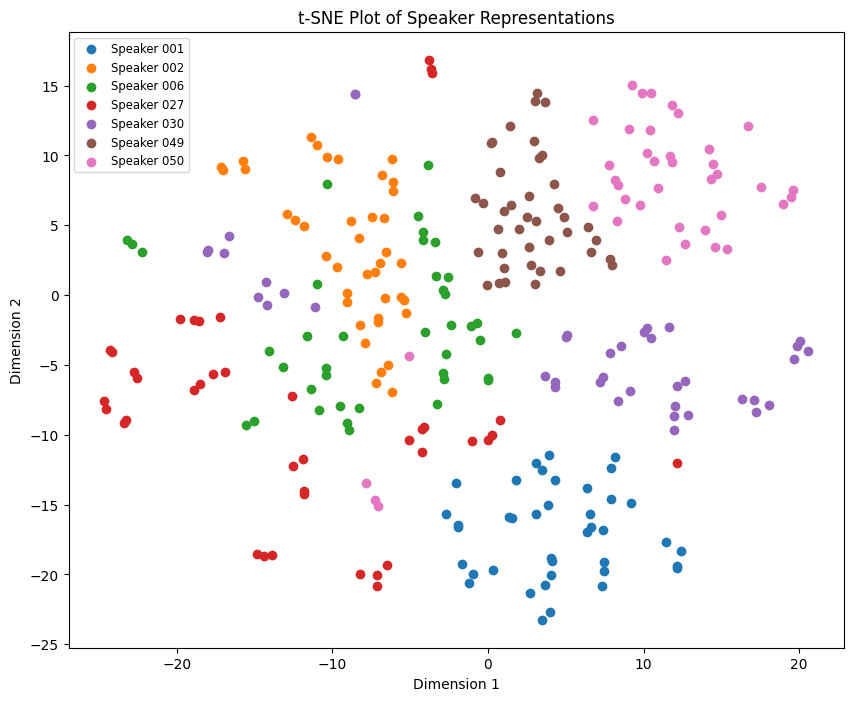

In [427]:


# # Function to load audio file (waveform) for ECAPA-TDNN input
# def load_audio(file_path, sample_rate=16000):
#     waveform, sr = torchaudio.load(file_path)
#     if sr != sample_rate:
#         waveform = torchaudio.transforms.Resample(orig_freq=sr, new_freq=sample_rate)(waveform)
#     return waveform

# # Function to extract 192-dimensional speaker representation using ECAPA TDNN
# def extract_speaker_representation(model, file_path):
#     waveform = load_audio(file_path)  # Load raw waveform
#     with torch.no_grad():
#         embedding = model.encode_batch(waveform).squeeze().cpu().numpy()
#     return embedding

# Function to extract filter bank features
# def extract_filter_bank_features(file_path, sample_rate=16000, n_mels=80, win_length=25, hop_length=10):
#     waveform, sr = torchaudio.load(file_path)
#     if sr != sample_rate:
#         waveform = torchaudio.transforms.Resample(orig_freq=sr, new_freq=sample_rate)(waveform)
#     #print("Sampling Rate", sr)
#     print("Before Mel", waveform.size())
#     # Create MelSpectrogram transform to extract filter bank features
#     mel_spectrogram = torchaudio.transforms.MelSpectrogram(
#         sample_rate=sample_rate,
#         n_fft=2*n_mels,  # Was: n_fft=2*n_mels --> Was computing mel features which are not supported in this version of speechbrain library, therefore use torchaudio to compute the mel spectrogram
#         win_length=win_length,  # 25 ms
#         hop_length=hop_length,  # 10 ms
#         n_mels=n_mels
#     )
#     # Apply the mel_spectrogram transform to the waveform
#     mel_spectrogram = mel_spectrogram(waveform)
#     print("After mel", mel_spectrogram.size())

#     # Pass the Mel-spectrogram to the ECAPA-TDNN model
#     # Reshape the mel_spectrogram to have a batch dimension
#     mel_spectrogram = mel_spectrogram.unsqueeze(0)
#     with torch.no_grad():
#         # Pass the reshaped mel_spectrogram to encode_batch
#         embeddings = teacher_model.encode_batch(mel_spectrogram)  # shape: [Batch
#     #print(embeddings.size())
#     # Removed the squeeze as the output was not being used
#     return embeddings.cpu().numpy() # Return 3D tensor # Return 3D tensor


# # Function to extract 192-dimensional speaker representation using ECAPA TDNN
# def extract_speaker_representation(model, file_path):
#     embeddings_res = extract_filter_bank_features(file_path)  # Extract filter bank features
#     #print(embeddings_res.size())
#     return embeddings_res


# Choose speakers
speakers = ['001', '002', '006', '027', '030', '049', '050']  # Example speaker IDs
sessions = ['A' ,'B', 'C', 'D']  # Sessions

# Store embeddings and labels
embeddings = []
labels = []

# Process 100 utterances per speaker (10 digits across 4 sessions -> 10 * 4 = 40 utterances)
utterances_per_speaker = 100
dataset_path = 'DigitUtter-IITDH-dataset-master'  # Update to your dataset path

spk_emb_encoder = MelSpectrogramEncoder.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb-mel-spec")


for speaker in speakers:
    print("Speaker", speaker)
    count = 0
    for session in sessions:
        for digit in range(10):  # Digits 0-9
            file_path = os.path.join(dataset_path, speaker, f"{speaker}{session}", f"{digit}.wav")
            ref_signal, fs_file = torchaudio.load(file_path)
            spk_embedding = spk_emb_encoder.encode_waveform(ref_signal)
            #print(spk_embedding.shape)
            #embedding = extract_speaker_representation(ecapa_model, file_path)
            #print("For file ... " + file_path + "==> Embedding size" + str(embedding.size()))
            embeddings.append(spk_embedding)
            labels.append(speaker)
            count += 1
            if count >= utterances_per_speaker:
                break
        if count >= utterances_per_speaker:
            break
print(len(embeddings))
# Convert to numpy array
embeddings = np.stack(embeddings, axis=0)
print(embeddings.shape)

embeddings = embeddings.reshape(embeddings.shape[0], -1) # Reshape to 2D

# Perform t-SNE to project into 2 dimensions
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=5000)
tsne_results = tsne.fit_transform(embeddings)



# Plot t-SNE results
plt.figure(figsize=(10, 8))
for i, speaker in enumerate(speakers):
    idx = [j for j, label in enumerate(labels) if label == speaker]
    plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], label=f'Speaker {speaker}')

plt.legend(loc='best', fontsize='small')
plt.title('t-SNE Plot of Speaker Representations')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()


In [393]:
# Custom dataset class
class DigitUtterDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.audio_paths = []
        self.labels = []
        self._prepare_data()

    def _prepare_data(self):
        # Assuming directory structure is `data_dir/speaker_id/session_x/audio.wav`
        speakers = sorted(os.listdir(self.data_dir))  # Sort speakers to assign consistent indices
        print(speakers)
        speakers.remove('.DS_Store')
        # Create a mapping from speaker names to integer indices
        speaker_to_index = {speaker: idx for idx, speaker in enumerate(speakers)}
        # Optional: If you need just the indices in a set
        speakers_mod = set(speaker_to_index.values())
        #print(speakers_mod)
        
        speaker_to_index = {speaker: idx for idx, speaker in enumerate(speakers)}  # Map to indices
    
        for speaker in speakers:
            speaker_path = os.path.join(dataset_path, speaker)
            #print("Speaker Path",speaker_path)
            if os.path.isdir(speaker_path):
                for session in ['A', 'B', 'C', 'D']:  # Iterate over sessions
                    session_path = os.path.join(speaker_path, f"{speaker}{session}")
                    #print("Session Path", session_path)
                    if os.path.isdir(session_path):
                        #print(session_path)
                        for audio_file in os.listdir(session_path):
                            #print("Audio File Path ", audio_file)
                            # Check if the file is a .wav file
                            if audio_file.endswith('.wav'):
                                audio_path = os.path.join(session_path, audio_file)
                                self.audio_paths.append(audio_path)
                                #print(speaker_to_index[speaker])
                                self.labels.append(speaker_to_index[speaker])  # Use speaker ID as label 
                            else:
                                print("Not wave file")
                            # Check for duplicates
                                # if audio_path not in unique_samples:
                                #     unique_samples.add(audio_path)
                                #     self.audio_paths.append(audio_path)
                                #     self.labels.append(speaker)
                                # else:
                                #     print(f"Duplicate found: {audio_path}")
                    else:
                        print("This is not directory ->", session_path)   
    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label = int(self.labels[idx])
        #print(f"Loading sample {idx}: {audio_path}, label: {label}")  # Debug statement

        audio, sample_rate = torchaudio.load(audio_path)  # Load audio file
        if self.transform:
            audio = self.transform(audio)
        return audio.squeeze(0), label  # Remove unnecessary channel dimension

    
# Custom collate function for padding
def collate_fn(batch):
    # Separate the batch into audio tensors and labels
    audios, labels = zip(*batch)

   # Calculate original lengths before padding
    lengths = torch.tensor([audio.shape[0] for audio in audios])

    # Pad all audio tensors to the length of the longest audio in the batch
    padded_audios = pad_sequence(audios, batch_first=True)  # Pads to [batch_size, max_len]

    labels = torch.tensor([int(label) for label in labels])

    return padded_audios, labels, lengths


In [394]:
# Load ECAPA TDNN pre-trained model
classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/ecapa_tdnn")



# Prepare the dataset
dataset = DigitUtterDataset(dataset_path)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

# Define the number of classes (number of unique speakers in your dataset)
num_classes = len(set(dataset.labels))  # Calculate number of speakers in the dataset
print(num_classes)
# Add a new linear layer to map embeddings to the number of classes
classifier.mods.Cclassifier = torch.nn.Linear(in_features=192, out_features=num_classes)  # 192 is the default embedding size for ECAPA-TDNN


# Define optimizer and loss function
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()

['.DS_Store', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']
Not wave file
50


In [395]:
# Get a batch of data
data_iter = iter(train_loader)
samples, labels, lengths = next(data_iter)

print("Samples shape:", samples.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Samples shape: torch.Size([16, 31335])
Labels shape: torch.Size([16])
Labels: tensor([13, 23, 37, 48, 12, 11, 41, 41, 26, 39, 45, 26, 14, 28, 31, 10])


In [396]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

# Fine-tuning loop
num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    classifier.train()  # Set model to training mode
    running_loss = 0.0

    for batch in train_loader:
        
        optimizer.zero_grad()

        audio, labels, lengths = batch
        # Pass the padded sequences directly to the ECAPA TDNN model
        embeddings = classifier.encode_batch(audio)  # Encode using ECAPA TDNN
        # Pass embeddings through the new linear classification head
        logits = classifier.mods.classifier(embeddings)
        # Logits has shape [batch_size, 1, num_classes], we need to remove the extra dimension
        logits = logits.squeeze(1)  # Now logits will have shape [batch_size, num_classes]
        # Compute loss
        loss = criterion(logits, labels)

        # print("Embeddings, Audio, Logits, Labels")
        # print(embeddings.shape)
        # print(audio.shape)
        # print(logits.shape)
        # print(labels.shape)
        # print(labels)
        # print("Loss ->", loss)
        # # Get unique elements and their counts
        # unique_elements, counts = torch.unique(labels, return_counts=True)
        # # Find elements that are duplicates
        # duplicates = unique_elements[counts > 1]
        # print("Duplicates:", duplicates)

        # Backward and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

torch.save(classifier.state_dict(), "fine_tuned_ecapa_tdnn.pth")


Epoch 1/50, Loss: 25.147416286468506
Epoch 2/50, Loss: 23.29869281768799
Epoch 3/50, Loss: 21.00362398147583
Epoch 4/50, Loss: 18.993318719863893
Epoch 5/50, Loss: 17.231417150497435
Epoch 6/50, Loss: 15.799074897766113
Epoch 7/50, Loss: 14.288901586532592
Epoch 8/50, Loss: 12.956040391921997
Epoch 9/50, Loss: 11.849328927993774
Epoch 10/50, Loss: 10.468297257423401
Epoch 11/50, Loss: 9.58066524028778
Epoch 12/50, Loss: 8.692464468479157
Epoch 13/50, Loss: 8.088634543418884
Epoch 14/50, Loss: 7.29810243844986
Epoch 15/50, Loss: 7.046521058082581
Epoch 16/50, Loss: 6.096523308753968
Epoch 17/50, Loss: 5.986750705242157
Epoch 18/50, Loss: 5.239765722751617
Epoch 19/50, Loss: 5.0098600101470945
Epoch 20/50, Loss: 4.516763921976089
Epoch 21/50, Loss: 4.209126838743686
Epoch 22/50, Loss: 4.025140427350998
Epoch 23/50, Loss: 3.6560416334867476
Epoch 24/50, Loss: 3.47186810195446
Epoch 25/50, Loss: 3.1853855729103087
Epoch 26/50, Loss: 3.020648095086217
Epoch 27/50, Loss: 2.7697658479213714
E

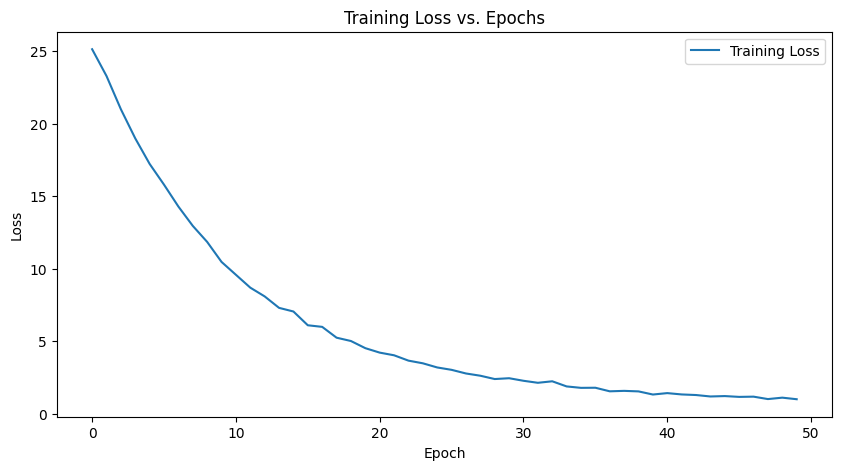

In [397]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs. Epochs')
plt.legend()
plt.show()

Ends here ------->